## 1 · Imports & Configuration

In [1]:
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout, InputLayer
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.utils import to_categorical, plot_model
from tensorflow.keras import regularizers

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, precision_score, recall_score, f1_score
)

sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams.update({
    'figure.dpi': 120,
    'font.family': 'DejaVu Sans',
    'axes.titlesize': 14,
    'axes.labelsize': 12,
})

ACCENT   = '#7C3AED'   #
ACCENT2  = '#06B6D4'  
RED      = '#EF4444'
GREEN    = '#22C55E'

print(f'TensorFlow {tf.__version__}  |  NumPy {np.__version__}')
print('GPU:', tf.config.list_physical_devices('GPU') or 'None – using CPU')

TensorFlow 2.19.0  |  NumPy 1.26.4
GPU: None – using CPU


In [2]:
# ── Configuration ────────────────────────────────────────────────────────
DATA_DIR        = 'features'
SEQUENCE_LENGTH = 30
FEATURES_DIM    = 447
NUM_CLASSES     = 40
MODEL_SAVE_PATH = 'signlingo_v2_gru_4.h5'
RANDOM_STATE    = 42
L2_RATE = 1e-4


## 2 · Data Loading & Exploration

Each **action** folder inside `features/` contains `.npy` files, one per recorded sequence.
Every sequence must have shape `(30, 447)` — 30 frames × 447 MediaPipe keypoints.

In [3]:
def load_data(data_dir):
    if not os.path.exists(data_dir):
        raise FileNotFoundError(f"Directory '{data_dir}' not found.")

    actions = sorted([
        d for d in os.listdir(data_dir)
        if os.path.isdir(os.path.join(data_dir, d))
    ])

    if len(actions) != NUM_CLASSES:
        print(f'⚠ Expected {NUM_CLASSES} classes, found {len(actions)}.')

    label_map = {label: num for num, label in enumerate(actions)}
    sequences, labels, skipped = [], [], 0

    for action in actions:
        action_path = os.path.join(data_dir, action)
        for seq_file in os.listdir(action_path):
            if not seq_file.endswith('.npy'):
                continue
            res = np.load(os.path.join(action_path, seq_file))
            if res.shape == (SEQUENCE_LENGTH, FEATURES_DIM):
                sequences.append(res)
                labels.append(label_map[action])
            else:
                skipped += 1

    X = np.array(sequences)
    y = to_categorical(labels, num_classes=len(actions)).astype(int)
    print(f'Loaded {X.shape[0]} sequences  |  Skipped {skipped} bad shapes')
    return X, y, actions, len(actions)


X, y, actions, num_classes = load_data(DATA_DIR)
print(f'X shape : {X.shape}   (samples × timesteps × features)')
print(f'y shape : {y.shape}   (samples × classes)')
print(f'Classes : {num_classes}')
print('Labels  :', actions)


Loaded 4628 sequences  |  Skipped 0 bad shapes
X shape : (4628, 30, 447)   (samples × timesteps × features)
y shape : (4628, 40)   (samples × classes)
Classes : 40
Labels  : ['Apa', 'Apa Kabar', 'Bagaimana', 'Baik', 'Belajar', 'Berapa', 'Berdiri', 'Bingung', 'Dia', 'Dimana', 'Duduk', 'Halo', 'Kalian', 'Kami', 'Kamu', 'Kapan', 'Kemana', 'Kita', 'Makan', 'Mandi', 'Marah', 'Melihat', 'Membaca', 'Menulis', 'Mereka', 'Minum', 'Pendek', 'Ramah', 'Sabar', 'Saya', 'Sedih', 'Selamat Malam', 'Selamat Pagi', 'Selamat Siang', 'Selamat Sore', 'Senang', 'Siapa', 'Terima Kasih', 'Tidur', 'Tinggi']


### 2.1 · Samples per Class

In [ ]:
y_int   = np.argmax(y, axis=1)
counts  = [np.sum(y_int == i) for i in range(num_classes)]

fig, ax = plt.subplots(figsize=(max(12, num_classes * 0.45), 5))
bars = ax.bar(actions, counts,
              color=plt.cm.plasma(np.linspace(0.15, 0.85, num_classes)),
              edgecolor='white', linewidth=0.6)
ax.set_title('Samples per Class', fontweight='bold')
ax.set_xlabel('Sign Label')
ax.set_ylabel('Number of Sequences')
ax.tick_params(axis='x', rotation=55)
for bar, cnt in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
            str(cnt), ha='center', va='bottom', fontsize=8, fontweight='bold')
plt.tight_layout()
plt.savefig('samples_per_class.pdf')
plt.show()
print(f'Min: {min(counts)}  |  Max: {max(counts)}  |  Mean: {np.mean(counts):.1f}')

In [5]:
# Make all the dataset sample uniform at 110
MAX_SAMPLES_PER_CLASS = 110
balanced_indices = []

# Convert one-hot labels back to integers to identify class groups
y_ints = np.argmax(y, axis=1)

for i in range(num_classes):
    # Get all indices belonging to this class
    class_indices = np.where(y_ints == i)[0]
    
    # Take up to 110 samples
    selected = class_indices[:MAX_SAMPLES_PER_CLASS]
    balanced_indices.extend(selected)

# Update X and y with the balanced subset
X = X[balanced_indices]
y = y[balanced_indices]

print(f"✅ Flattening complete.")
print(f"New X shape: {X.shape}")
print(f"New y shape: {y.shape}")

# Verify the count
unique, counts = np.unique(np.argmax(y, axis=1), return_counts=True)
print("Samples per class:", dict(zip(actions, counts)))


✅ Flattening complete.
New X shape: (4400, 30, 447)
New y shape: (4400, 40)
Samples per class: {'Apa': 110, 'Apa Kabar': 110, 'Bagaimana': 110, 'Baik': 110, 'Belajar': 110, 'Berapa': 110, 'Berdiri': 110, 'Bingung': 110, 'Dia': 110, 'Dimana': 110, 'Duduk': 110, 'Halo': 110, 'Kalian': 110, 'Kami': 110, 'Kamu': 110, 'Kapan': 110, 'Kemana': 110, 'Kita': 110, 'Makan': 110, 'Mandi': 110, 'Marah': 110, 'Melihat': 110, 'Membaca': 110, 'Menulis': 110, 'Mereka': 110, 'Minum': 110, 'Pendek': 110, 'Ramah': 110, 'Sabar': 110, 'Saya': 110, 'Sedih': 110, 'Selamat Malam': 110, 'Selamat Pagi': 110, 'Selamat Siang': 110, 'Selamat Sore': 110, 'Senang': 110, 'Siapa': 110, 'Terima Kasih': 110, 'Tidur': 110, 'Tinggi': 110}


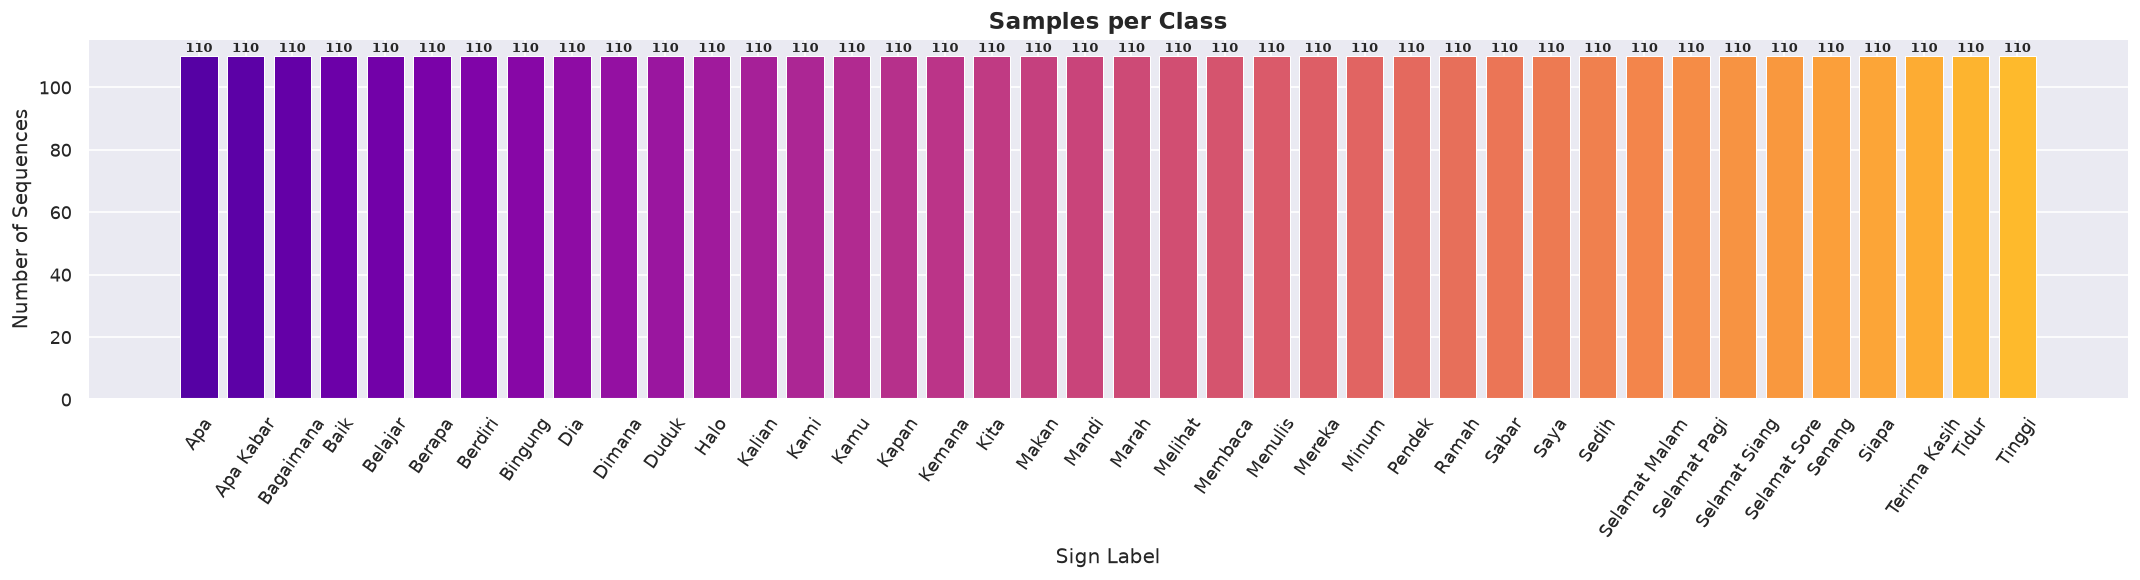

Min: 110  |  Max: 110  |  Mean: 110.0


In [6]:
y_int   = np.argmax(y, axis=1)
counts  = [np.sum(y_int == i) for i in range(num_classes)]

fig, ax = plt.subplots(figsize=(max(12, num_classes * 0.45), 5))
bars = ax.bar(actions, counts,
              color=plt.cm.plasma(np.linspace(0.15, 0.85, num_classes)),
              edgecolor='white', linewidth=0.6)
ax.set_title('Samples per Class', fontweight='bold')
ax.set_xlabel('Sign Label')
ax.set_ylabel('Number of Sequences')
ax.tick_params(axis='x', rotation=55)
for bar, cnt in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
            str(cnt), ha='center', va='bottom', fontsize=8, fontweight='bold')
plt.tight_layout()
plt.show()
print(f'Min: {min(counts)}  |  Max: {max(counts)}  |  Mean: {np.mean(counts):.1f}')


## 3 · Train / Validation / Test Split

**80% train · 10% validation · 10% test** with stratified sampling to keep class balance.

In [7]:
# 80 / 20
try:
    X_train, X_temp, y_train, y_temp = train_test_split(
        X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE)
except ValueError:
    print('Falling back to non-stratified split (first stage).')
    X_train, X_temp, y_train, y_temp = train_test_split(
        X, y, test_size=0.20, random_state=RANDOM_STATE)

# 10 / 10  (split the 20%)
try:
    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=RANDOM_STATE)
except ValueError:
    print('Falling back to non-stratified split (second stage).')
    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp, test_size=0.50, random_state=RANDOM_STATE)

print(f'Train : {X_train.shape[0]:>5} samples')
print(f'Val   : {X_val.shape[0]:>5} samples')
print(f'Test  : {X_test.shape[0]:>5} samples')


Train :  3520 samples
Val   :   440 samples
Test  :   440 samples


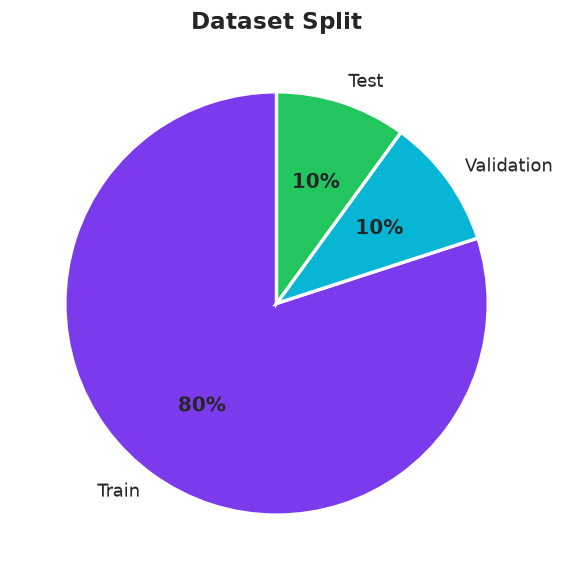

In [8]:
split_sizes = [X_train.shape[0], X_val.shape[0], X_test.shape[0]]
split_labels = ['Train', 'Validation', 'Test']
split_colors = [ACCENT, ACCENT2, GREEN]

fig, ax = plt.subplots(figsize=(5, 5))
wedges, texts, autotexts = ax.pie(
    split_sizes,
    labels=split_labels,
    colors=split_colors,
    autopct='%1.0f%%',
    startangle=90,
    wedgeprops=dict(edgecolor='white', linewidth=2),
)
for at in autotexts:
    at.set(fontweight='bold', fontsize=12)
ax.set_title('Dataset Split', fontweight='bold')
plt.tight_layout()
plt.show()


In [9]:
def augment_sequence(data):
    """Applies a random combination of augmentations to a single sequence (30, 447)"""
    aug_data = data.copy()

    # 1. Gaussian Noise Injection (Jitter)
    # sigma=0.005 is subtle but effective for normalized landmarks
    noise = np.random.normal(0, 0.005, aug_data.shape)
    aug_data += noise

    # Reshape to (30, 149, 3) for spatial transforms (X, Y, Z triplets)
    aug_data = aug_data.reshape(30, -1, 3)

    # 2. Spatial Scaling (Uniformly scale by ±5%)
    scale = np.random.uniform(0.95, 1.05)
    aug_data *= scale

    # 3. Rotational Transformation (Minor rotation 3-5 degrees)
    angle = np.radians(np.random.uniform(3, 5) * np.random.choice([-1, 1]))
    c, s = np.cos(angle), np.sin(angle)
    # Rotation matrix for Z-axis (plane of the image)
    R = np.array([[c, -s, 0], [s, c, 0], [0, 0, 1]])
    aug_data = np.dot(aug_data, R)

    # Flatten back to original feature dimension (447)
    aug_data = aug_data.reshape(30, 447)

    # 4. Temporal Stretching (Systematically duplicate or omit frames ~10%)
    stretch = np.random.uniform(0.9, 1.1)
    new_len = int(30 * stretch)
    
    # Resample and interpolate back to 30 frames to maintain input shape
    stretched_data = np.zeros((30, 447))
    for f in range(447):
        # Interpolate the sequence over the new timeline
        stretched_data[:, f] = np.interp(
            np.linspace(0, 29, 30), 
            np.linspace(0, 29, new_len), 
            np.interp(np.linspace(0, 29, new_len), np.arange(30), aug_data[:, f])
        )

    return stretched_data

def apply_augmentation_pipeline(X, y, multiplier=2): # Multiplier is exchange able
    """Creates augmented copies of the training set"""
    X_aug_list, y_aug_list = [X], [y]
    
    print(f"Generating {X.shape[0] * multiplier} augmented samples...")
    for i in range(multiplier):
        X_new = np.array([augment_sequence(sample) for sample in X])
        X_aug_list.append(X_new)
        y_aug_list.append(y)
    
    X_final = np.concatenate(X_aug_list, axis=0)
    y_final = np.concatenate(y_aug_list, axis=0)
    
    # Shuffle the final augmented training set
    idx = np.random.permutation(len(X_final))
    return X_final[idx], y_final[idx]


In [10]:
# We only augment the training set. Val and Test must remain original for clean evaluation.
X_train_aug, y_train_aug = apply_augmentation_pipeline(X_train, y_train, multiplier=2)

print(f"Original Training Samples: {X_train.shape[0]}")
print(f"Augmented Training Samples: {X_train_aug.shape[0]}")

Generating 7040 augmented samples...
Original Training Samples: 3520
Augmented Training Samples: 10560


In [11]:
print(f'Train : {X_train_aug.shape[0]:>5} samples')
print(f'Val   : {X_val.shape[0]:>5} samples')
print(f'Test  : {X_test.shape[0]:>5} samples')

Train : 10560 samples
Val   :   440 samples
Test  :   440 samples


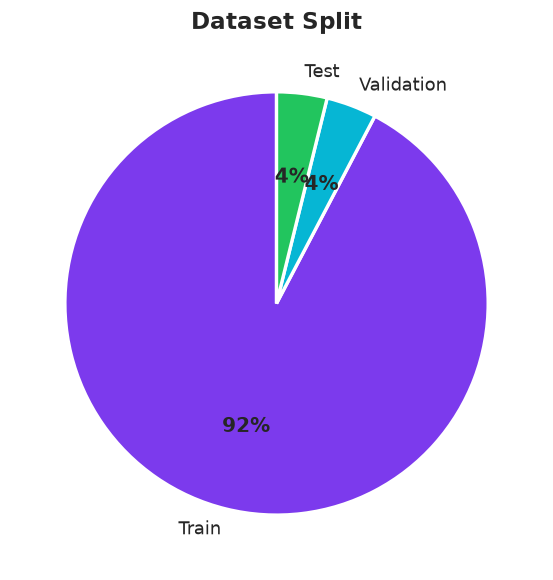

In [12]:
split_sizes = [X_train_aug.shape[0], X_val.shape[0], X_test.shape[0]]
split_labels = ['Train', 'Validation', 'Test']
split_colors = [ACCENT, ACCENT2, GREEN]

fig, ax = plt.subplots(figsize=(5, 5))
wedges, texts, autotexts = ax.pie(
    split_sizes,
    labels=split_labels,
    colors=split_colors,
    autopct='%1.0f%%',
    startangle=90,
    wedgeprops=dict(edgecolor='white', linewidth=2),
)
for at in autotexts:
    at.set(fontweight='bold', fontsize=12)
ax.set_title('Dataset Split', fontweight='bold')
plt.tight_layout()
plt.show()


## 4 · Model Architecture

A two-layer **GRU** network with dropout regularisation, ending in a `softmax` classifier.

In [13]:
model = Sequential([
    InputLayer(input_shape=(SEQUENCE_LENGTH, FEATURES_DIM)),
    GRU(64, return_sequences=True, name='gru_1',
        kernel_regularizer=regularizers.l2(L2_RATE),
        recurrent_regularizer=regularizers.l2(L2_RATE)),
    Dropout(0.2, name='dropout_1'),
    GRU(64, return_sequences=False, name='gru_2',
        kernel_regularizer=regularizers.l2(L2_RATE),
        recurrent_regularizer=regularizers.l2(L2_RATE)),
    Dropout(0.2, name='dropout_2'),
    Dense(num_classes, activation='softmax', name='output',
          kernel_regularizer=regularizers.l2(L2_RATE)),
], name='SignLingo_GRU')

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
model.summary()


Model: "SignLingo_GRU"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_1 (GRU)                     │ (None, 30, 64)         │        98,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_2 (GRU)                     │ (None, 64)             │        24,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 40)             │         2,600 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 126,056 (492.41 KB)

 Trainable params: 126,056 (492.41 KB)

 Non-trainable params: 0 (0.00 B)

In [27]:
# ── Visual architecture diagram ───────────────────────────────────────────
try:
    from tensorflow.keras.utils import plot_model
    plot_model(
        model,
        to_file='model_architecture.png',
        show_shapes=True,
        show_layer_names=True,
        show_layer_activations=True,
        rankdir='TB',
        dpi=120,
    )
    from IPython.display import Image, display
    display(Image('model_architecture.png'))
except Exception as e:
    print(f'plot_model unavailable ({e}). Rendering text diagram instead.')

    # ── Text-based architecture visual ────────────────────────────────────
    layers_info = [
        ('Input',    f'({SEQUENCE_LENGTH}, {FEATURES_DIM})', ''),
        ('GRU-1',    '(30, 64)',                             'units=64, return_seq=True'),
        ('Dropout',  '(30, 64)',                             'rate=0.2'),
        ('GRU-2',    '(64,)',                                'units=64, return_seq=False'),
        ('Dropout',  '(64,)',                                'rate=0.2'),
        ('Dense',    f'({num_classes},)',                    'softmax'),
    ]

    colors = [ACCENT2, ACCENT, '#F59E0B', ACCENT, '#F59E0B', GREEN]
    fig, ax = plt.subplots(figsize=(8, len(layers_info) * 1.1))
    ax.set_xlim(0, 8)
    ax.set_ylim(-0.5, len(layers_info))
    ax.axis('off')

    for i, (name, shape, detail) in enumerate(reversed(layers_info)):
        y_pos = i
        color = colors[len(layers_info) - 1 - i]
        rect = mpatches.FancyBboxPatch(
            (1, y_pos - 0.38), 6, 0.76,
            boxstyle='round,pad=0.05',
            facecolor=color, edgecolor='white', linewidth=1.5, alpha=0.92
        )
        ax.add_patch(rect)
        ax.text(2.1, y_pos, f'{name}', va='center', ha='left',
                fontsize=12, fontweight='bold', color='white')
        ax.text(5.0, y_pos + 0.15, shape, va='center', ha='left',
                fontsize=9, color='white', alpha=0.9)
        ax.text(5.0, y_pos - 0.18, detail, va='center', ha='left',
                fontsize=8, color='white', alpha=0.75)

        if i < len(layers_info) - 1:
            ax.annotate('', xy=(4, y_pos + 0.42), xytext=(4, y_pos + 0.58),
                        arrowprops=dict(arrowstyle='->', color='white', lw=1.5))

    ax.set_title('SignLingo GRU Architecture', fontweight='bold',
                 fontsize=15, color='white', pad=12)
    fig.patch.set_facecolor('#1E1B4B')
    ax.set_facecolor('#1E1B4B')
    plt.tight_layout()
    plt.show()


You must install pydot (`pip install pydot`) for `plot_model` to work.


FileNotFoundError: No such file or directory: 'model_architecture.png'

FileNotFoundError: No such file or directory: 'model_architecture.png'

<IPython.core.display.Image object>

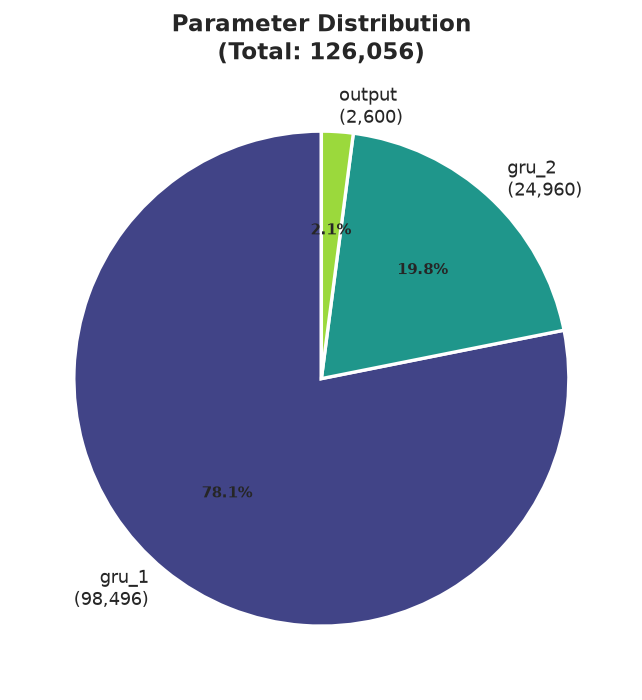

In [15]:
# ── Parameter breakdown pie chart ────────────────────────────────────────
param_data = {}
for layer in model.layers:
    p = layer.count_params()
    if p > 0:
        param_data[layer.name] = p

if param_data:
    fig, ax = plt.subplots(figsize=(6, 6))
    wedge_colors = plt.cm.viridis(np.linspace(0.2, 0.85, len(param_data)))
    wedges, texts, autotexts = ax.pie(
        list(param_data.values()),
        labels=[f'{n}\n({v:,})' for n, v in param_data.items()],
        colors=wedge_colors,
        autopct='%1.1f%%',
        startangle=90,
        wedgeprops=dict(edgecolor='white', linewidth=2),
    )
    for at in autotexts:
        at.set(fontsize=9, fontweight='bold')
    total = sum(param_data.values())
    ax.set_title(f'Parameter Distribution\n(Total: {total:,})', fontweight='bold')
    plt.tight_layout()
    plt.show()


## 5 · Callbacks & Training

| Callback | Setting |
|----------|---------|
| `EarlyStopping` | `patience=15`, restores best weights |
| `ReduceLROnPlateau` | `factor=0.5`, `patience=5`, `min_lr=1e-6` |
| `ModelCheckpoint` | saves best val_loss → `signlingo_v2_gru.h5` |


In [16]:
early_stopping = EarlyStopping(
    monitor='val_loss', patience=15,
    restore_best_weights=True, verbose=1
)
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss', factor=0.5,
    patience=5, min_lr=1e-6, verbose=1
)
checkpoint = ModelCheckpoint(
    MODEL_SAVE_PATH, monitor='val_loss',
    save_best_only=True, verbose=1
)

print('Starting training …')
history = model.fit(
    X_train_aug, y_train_aug,
    validation_data=(X_val, y_val),
    epochs=150,
    callbacks=[early_stopping, reduce_lr, checkpoint],
)
print('Training complete!')


Starting training …
Epoch 1/150
329/330 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.3009 - loss: 2.4493
Epoch 1: val_loss improved from None to 1.36748, saving model to signlingo_v2_gru_4.h5



Epoch 1: finished saving model to signlingo_v2_gru_4.h5
330/330 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - accuracy: 0.3018 - loss: 2.4464 - val_accuracy: 0.6545 - val_loss: 1.3675 - learning_rate: 0.0010
Epoch 2/150
329/330 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7182 - loss: 1.0340
Epoch 2: val_loss improved from 1.36748 to 0.64133, saving model to signlingo_v2_gru_4.h5



Epoch 2: finished saving model to signlingo_v2_gru_4.h5
330/330 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.7188 - loss: 1.0324 - val_accuracy: 0.8591 - val_loss: 0.6413 - learning_rate: 0.0010
Epoch 3/150
328/330 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8742 - loss: 0.5571
Epoch 3: val_loss improved from 0.64133 to 0.43213, saving model to signlingo_v2_gru_4.h5



Epoch 3: finished saving model to signlingo_v2_gru_4.h5
330/330 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.8742 - loss: 0.5565 - val_accuracy: 0.9000 - val_loss: 0.4321 - learning_rate: 0.0010
Epoch 4/150
330/330 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9167 - loss: 0.3915
Epoch 4: val_loss improved from 0.43213 to 0.34301, saving model to signlingo_v2_gru_4.h5



Epoch 4: finished saving model to signlingo_v2_gru_4.h5
330/330 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.9167 - loss: 0.3915 - val_accuracy: 0.9182 - val_loss: 0.3430 - learning_rate: 0.0010
Epoch 5/150
330/330 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9487 - loss: 0.2905
Epoch 5: val_loss improved from 0.34301 to 0.26179, saving model to signlingo_v2_gru_4.h5


...


Epoch 64: finished saving model to signlingo_v2_gru_4.h5
330/330 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.9994 - loss: 0.0701 - val_accuracy: 0.9955 - val_loss: 0.0825 - learning_rate: 2.5000e-04
Epoch 65/150
330/330 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9981 - loss: 0.0747
Epoch 65: val_loss did not improve from 0.08247
330/330 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.9981 - loss: 0.0747 - val_accuracy: 0.9909 - val_loss: 0.1045 - learning_rate: 2.5000e-04
Epoch 66/150
326/330 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9997 - loss: 0.0682
Epoch 66: val_loss did not improve from 0.08247
330/330 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.9997 - loss: 0.0682 - val_accuracy: 0.9886 - val_loss: 0.0913 - learning_rate: 2.5000e-04
Epoch 67/150
326/330 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 1.0000 - loss: 0.0657
Epoch 67: val_loss did not improve from 0.08247
330/330 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 1.0000 - loss: 0.0657 - val_accuracy: 0


Epoch 77: finished saving model to signlingo_v2_gru_4.h5
330/330 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 1.0000 - loss: 0.0607 - val_accuracy: 0.9932 - val_loss: 0.0823 - learning_rate: 6.2500e-05
Epoch 78/150
328/330 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9999 - loss: 0.0605
Epoch 78: val_loss did not improve from 0.08229
330/330 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.9999 - loss: 0.0605 - val_accuracy: 0.9909 - val_loss: 0.0857 - learning_rate: 6.2500e-05
Epoch 79/150
329/330 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 1.0000 - loss: 0.0599
Epoch 79: val_loss did not improve from 0.08229
330/330 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 1.0000 - loss: 0.0599 - val_accuracy: 0.9909 - val_loss: 0.0851 - learning_rate: 6.2500e-05
Epoch 80/150
327/330 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 1.0000 - loss: 0.0595
Epoch 80: val_loss did not improve from 0.08229
330/330 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 1.0000 - loss: 0.0595 - val_accuracy: 0


Epoch 82: finished saving model to signlingo_v2_gru_4.h5
330/330 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.9998 - loss: 0.0596 - val_accuracy: 0.9886 - val_loss: 0.0820 - learning_rate: 6.2500e-05
Epoch 83/150
328/330 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 1.0000 - loss: 0.0586
Epoch 83: val_loss did not improve from 0.08202
330/330 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 1.0000 - loss: 0.0585 - val_accuracy: 0.9909 - val_loss: 0.0863 - learning_rate: 6.2500e-05
Epoch 84/150
326/330 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 1.0000 - loss: 0.0581
Epoch 84: val_loss did not improve from 0.08202
330/330 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 1.0000 - loss: 0.0581 - val_accuracy: 0.9909 - val_loss: 0.0856 - learning_rate: 6.2500e-05
Epoch 85/150
328/330 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 1.0000 - loss: 0.0574
Epoch 85: val_loss did not improve from 0.08202
330/330 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 1.0000 - loss: 0.0574 - val_accuracy: 0


Epoch 87: finished saving model to signlingo_v2_gru_4.h5
330/330 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 1.0000 - loss: 0.0571 - val_accuracy: 0.9932 - val_loss: 0.0796 - learning_rate: 6.2500e-05
Epoch 88/150
326/330 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9999 - loss: 0.0566
Epoch 88: val_loss improved from 0.07962 to 0.07837, saving model to signlingo_v2_gru_4.h5



Epoch 88: finished saving model to signlingo_v2_gru_4.h5
330/330 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.9999 - loss: 0.0566 - val_accuracy: 0.9932 - val_loss: 0.0784 - learning_rate: 6.2500e-05
Epoch 89/150
330/330 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9999 - loss: 0.0565
Epoch 89: val_loss did not improve from 0.07837
330/330 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.9999 - loss: 0.0565 - val_accuracy: 0.9909 - val_loss: 0.0824 - learning_rate: 6.2500e-05
Epoch 90/150
326/330 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9998 - loss: 0.0570
Epoch 90: val_loss did not improve from 0.07837
330/330 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.9998 - loss: 0.0570 - val_accuracy: 0.9886 - val_loss: 0.0814 - learning_rate: 6.2500e-05
Epoch 91/150
327/330 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9991 - loss: 0.0591
Epoch 91: val_loss did not improve from 0.07837
330/330 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.9991 - loss: 0.0591 - val_accuracy: 0

## 6 · Training Curves

Visualise **loss** and **accuracy** over every epoch for both train and validation sets.

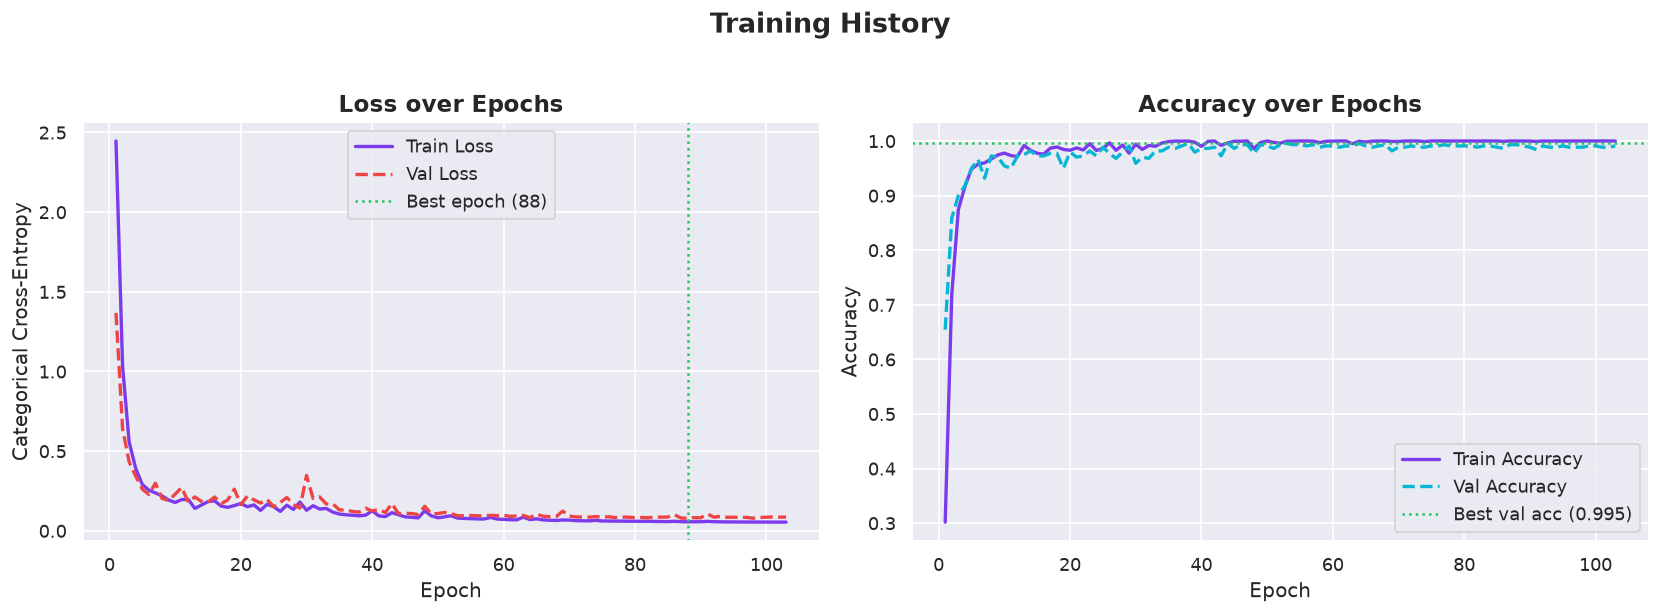

In [17]:
hist = history.history
epochs_ran = range(1, len(hist['loss']) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Loss ─────────────────────────────────────────────────────────────────
ax = axes[0]
ax.plot(epochs_ran, hist['loss'],     color=ACCENT,  lw=2,   label='Train Loss')
ax.plot(epochs_ran, hist['val_loss'], color=RED,     lw=2,   label='Val Loss', linestyle='--')
best_epoch = int(np.argmin(hist['val_loss'])) + 1
ax.axvline(best_epoch, color=GREEN, lw=1.5, linestyle=':', label=f'Best epoch ({best_epoch})')
ax.set_title('Loss over Epochs', fontweight='bold')
ax.set_xlabel('Epoch')
ax.set_ylabel('Categorical Cross-Entropy')
ax.legend()

# ── Accuracy ──────────────────────────────────────────────────────────────
ax = axes[1]
ax.plot(epochs_ran, hist['accuracy'],     color=ACCENT,  lw=2,   label='Train Accuracy')
ax.plot(epochs_ran, hist['val_accuracy'], color=ACCENT2, lw=2,   label='Val Accuracy',   linestyle='--')
best_val_acc = max(hist['val_accuracy'])
ax.axhline(best_val_acc, color=GREEN, lw=1.5, linestyle=':', label=f'Best val acc ({best_val_acc:.3f})')
ax.set_title('Accuracy over Epochs', fontweight='bold')
ax.set_xlabel('Epoch')
ax.set_ylabel('Accuracy')
ax.legend()

plt.suptitle('Training History', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


In [18]:
if 'lr' in hist:
    fig, ax = plt.subplots(figsize=(8, 3))
    ax.plot(epochs_ran, hist['lr'], color=ACCENT2, lw=2)
    ax.set_title('Learning Rate Schedule', fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Learning Rate')
    ax.set_yscale('log')
    plt.tight_layout()
    plt.show()


## 7 · Final Evaluation on the Test Set

In [19]:
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f'Test Loss     : {test_loss:.4f}')
print(f'Test Accuracy : {test_accuracy * 100:.2f}%')

# Predicted labels
y_pred_probs = model.predict(X_test, verbose=0)
y_pred       = np.argmax(y_pred_probs, axis=1)
y_true       = np.argmax(y_test, axis=1)

# Summary metrics
prec = precision_score(y_true, y_pred, average='weighted', zero_division=0)
rec  = recall_score(y_true, y_pred, average='weighted', zero_division=0)
f1   = f1_score(y_true, y_pred, average='weighted', zero_division=0)

print(f'\nWeighted Precision : {prec:.4f}')
print(f'Weighted Recall    : {rec:.4f}')
print(f'Weighted F1 Score  : {f1:.4f}')


Test Loss     : 0.0776
Test Accuracy : 99.55%

Weighted Precision : 0.9958
Weighted Recall    : 0.9955
Weighted F1 Score  : 0.9954


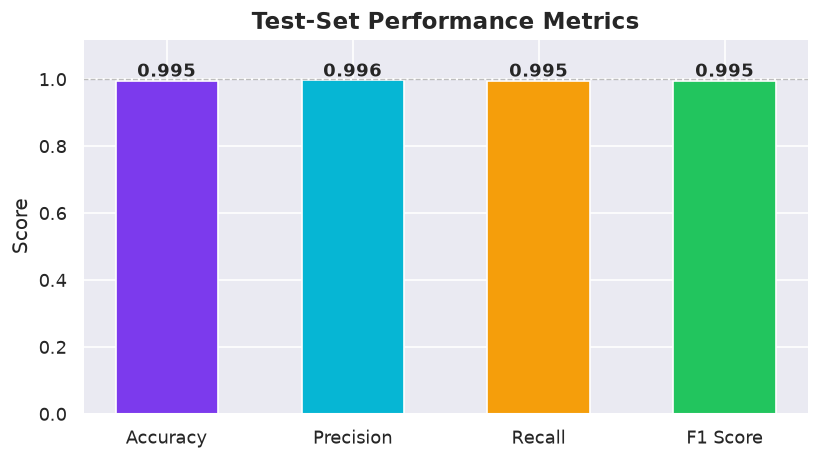

In [20]:
metrics   = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
vals      = [test_accuracy, prec, rec, f1]
bar_colors= [ACCENT, ACCENT2, '#F59E0B', GREEN]

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(metrics, vals, color=bar_colors,
              edgecolor='white', linewidth=1, width=0.55)
ax.set_ylim(0, 1.12)
ax.axhline(1.0, color='grey', lw=0.8, linestyle='--', alpha=0.5)
for bar, val in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.012,
            f'{val:.3f}', ha='center', fontsize=11, fontweight='bold')
ax.set_title('Test-Set Performance Metrics', fontweight='bold')
ax.set_ylabel('Score')
plt.tight_layout()
plt.show()


## 8 · Confusion Matrix

Rows = true class · Columns = predicted class.  
The diagonal shows correct predictions; off-diagonal cells show misclassifications.

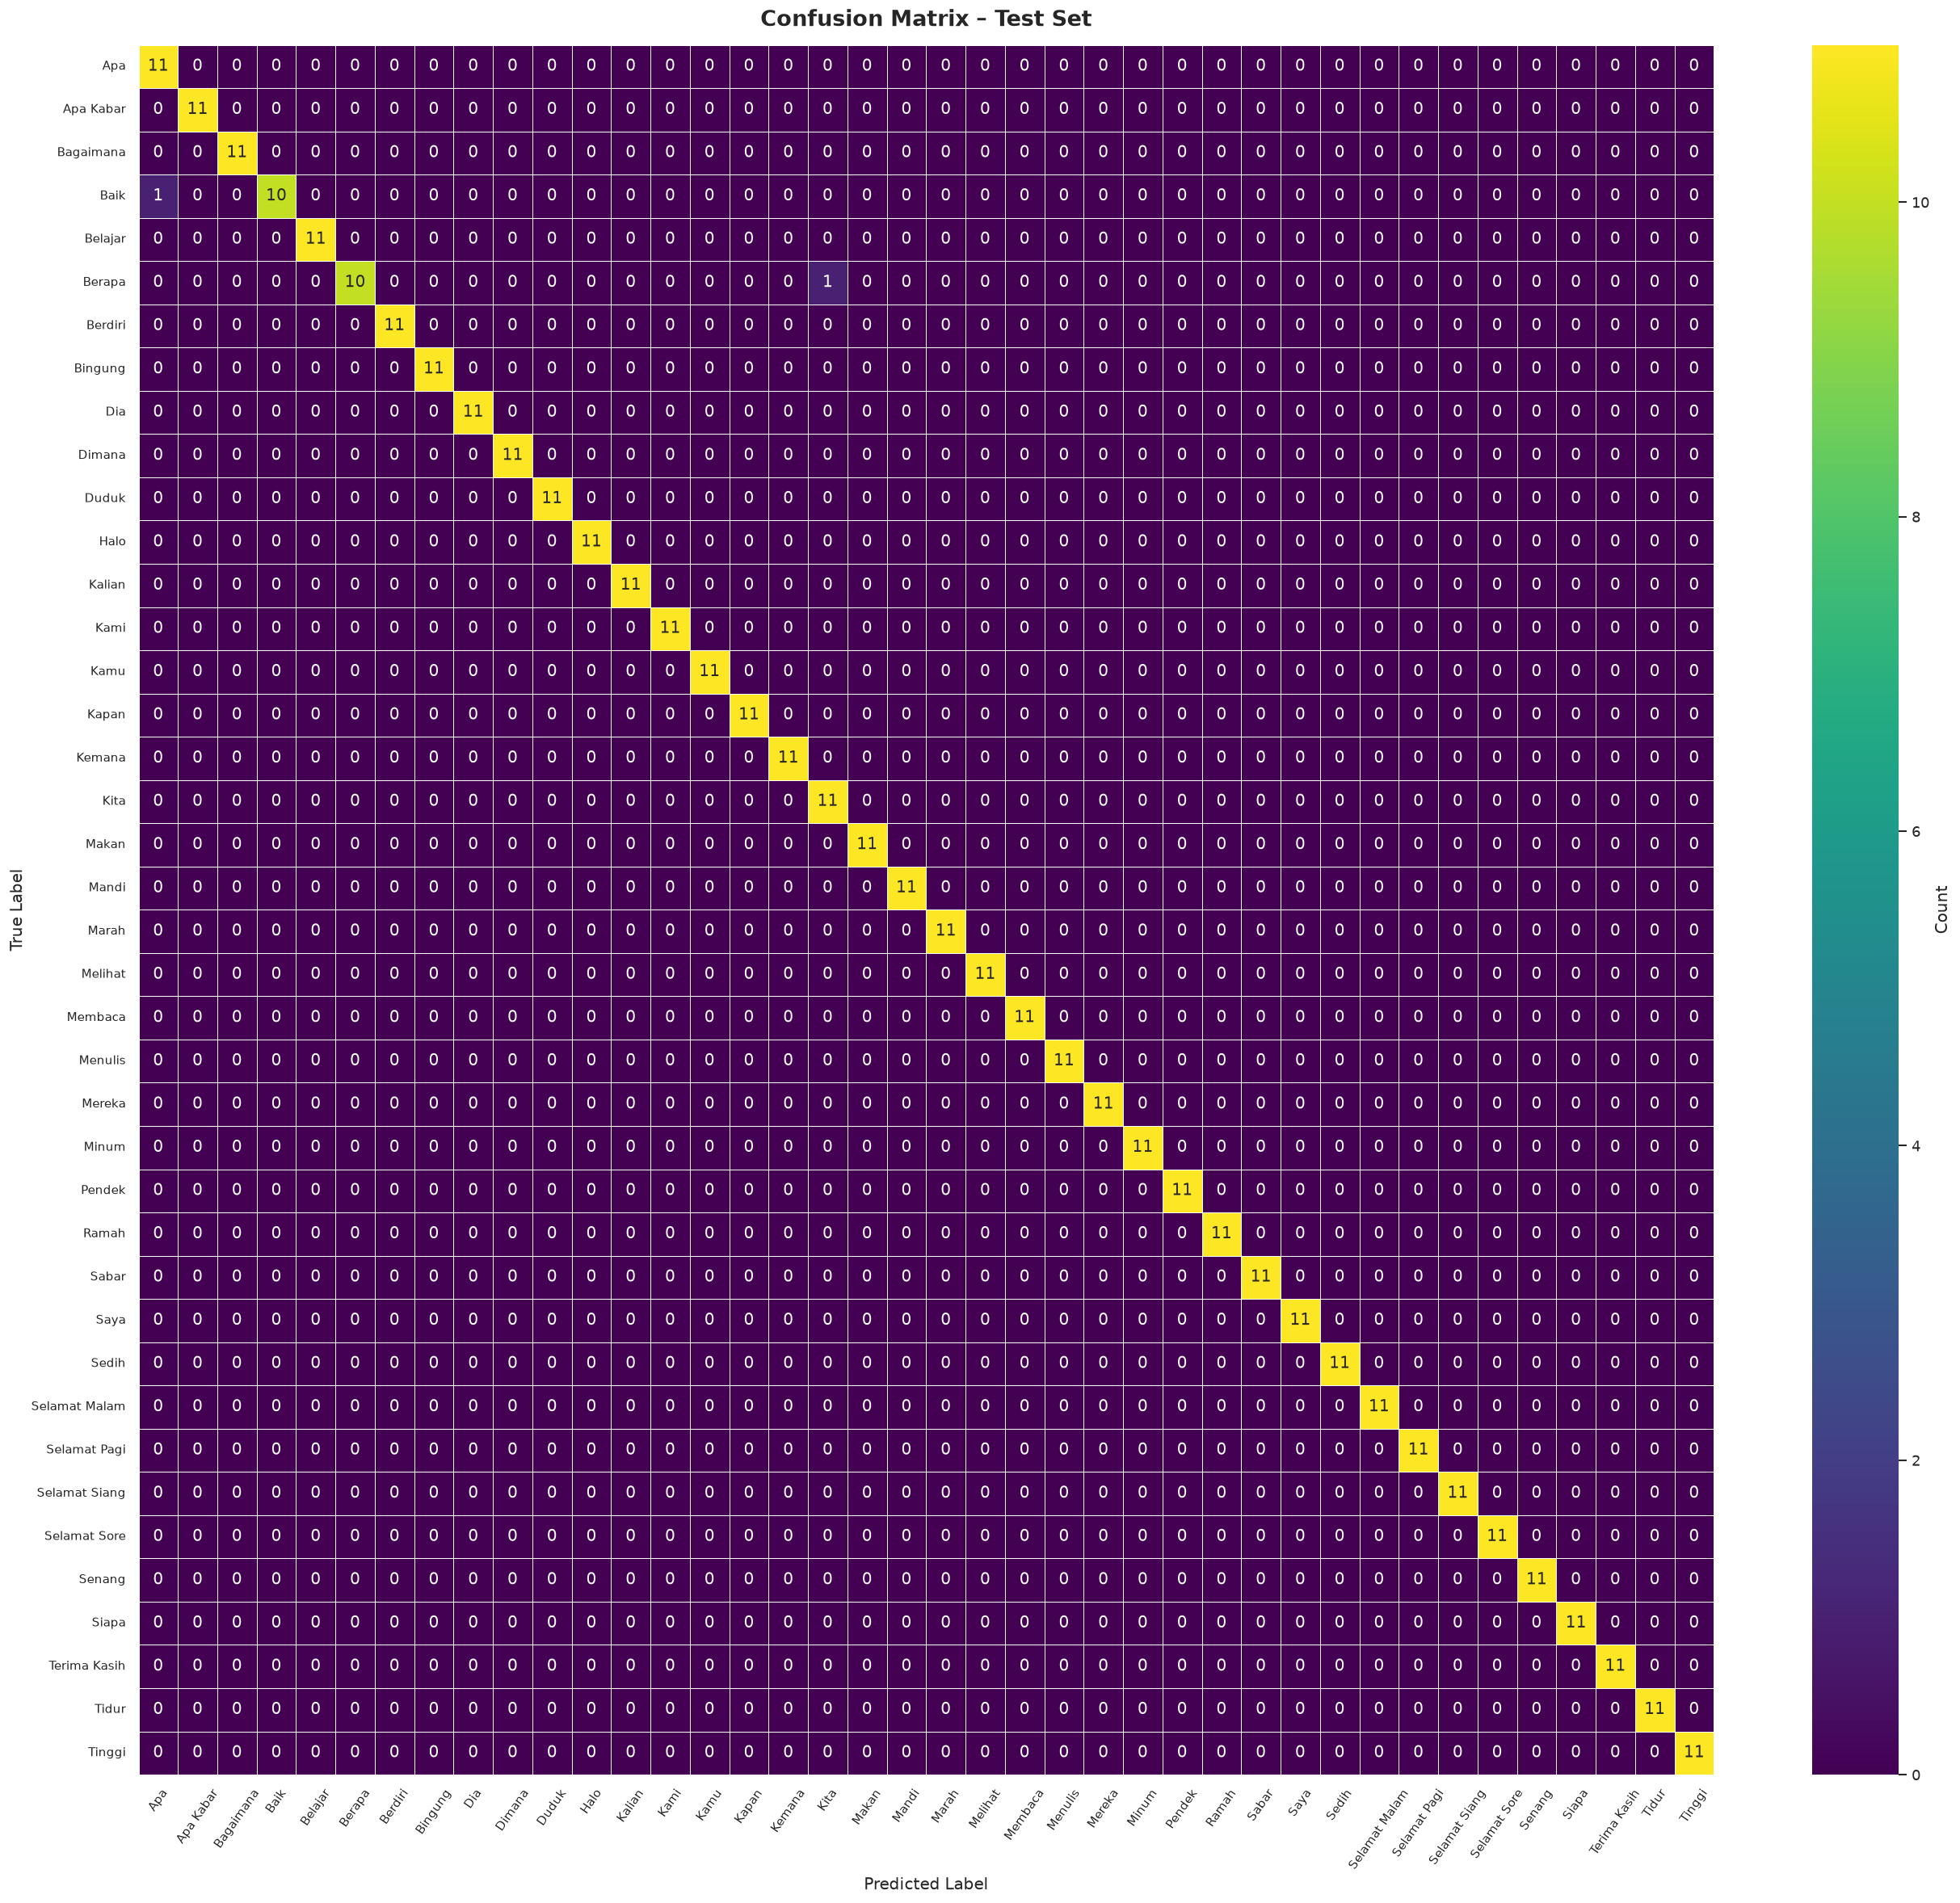

In [21]:
cm = confusion_matrix(y_true, y_pred)

fig_size = max(12, num_classes * 0.55)
fig, ax = plt.subplots(figsize=(fig_size, fig_size * 0.9))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='viridis',
    xticklabels=actions,
    yticklabels=actions,
    linewidths=0.5,
    linecolor='white',
    ax=ax,
    cbar_kws={'label': 'Count'},
)
ax.set_title('Confusion Matrix – Test Set', fontweight='bold', fontsize=16, pad=14)
ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_ylabel('True Label', fontsize=12)
ax.tick_params(axis='x', rotation=55, labelsize=9)
ax.tick_params(axis='y', rotation=0, labelsize=9)
plt.tight_layout()
plt.show()


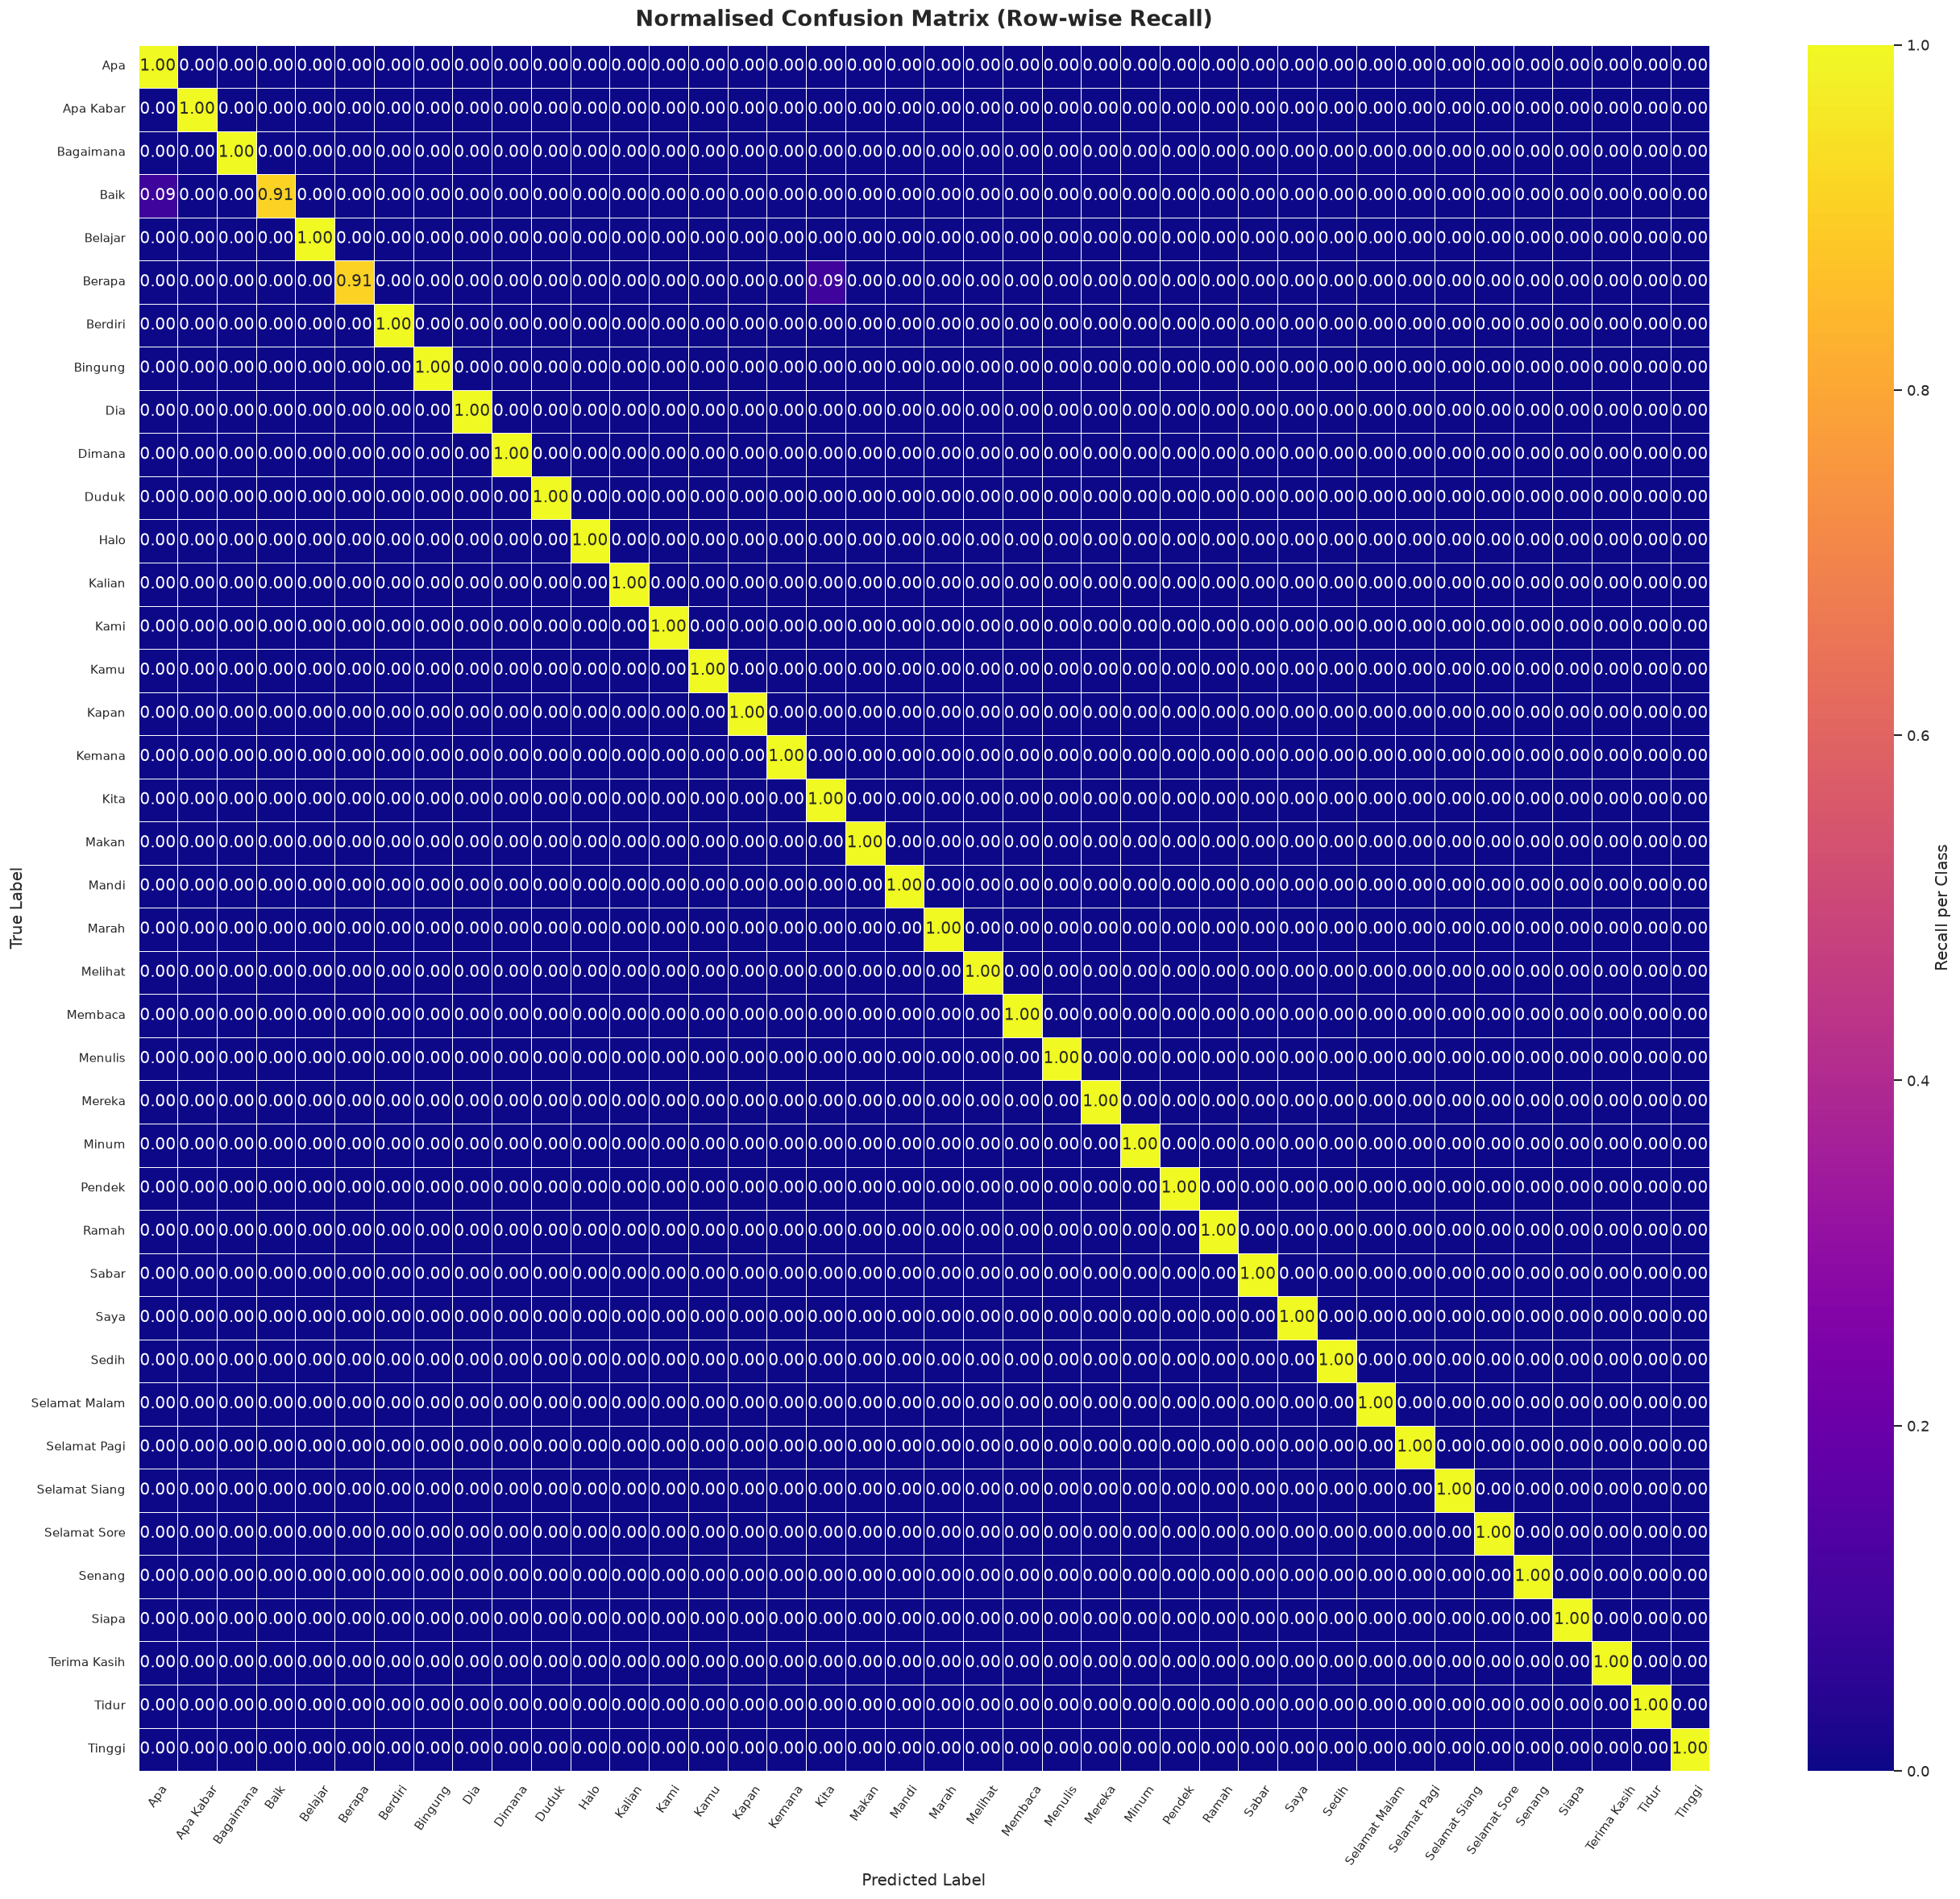

In [22]:
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(fig_size, fig_size * 0.9))
sns.heatmap(
    cm_norm,
    annot=True,
    fmt='.2f',
    cmap='plasma',
    xticklabels=actions,
    yticklabels=actions,
    linewidths=0.5,
    linecolor='white',
    vmin=0, vmax=1,
    ax=ax,
    cbar_kws={'label': 'Recall per Class'},
)
ax.set_title('Normalised Confusion Matrix (Row-wise Recall)', fontweight='bold', fontsize=16, pad=14)
ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_ylabel('True Label', fontsize=12)
ax.tick_params(axis='x', rotation=55, labelsize=9)
ax.tick_params(axis='y', rotation=0, labelsize=9)
plt.tight_layout()
plt.show()


## 9 · Per-Class Metrics

Detailed precision, recall, and F1 for each individual sign class.

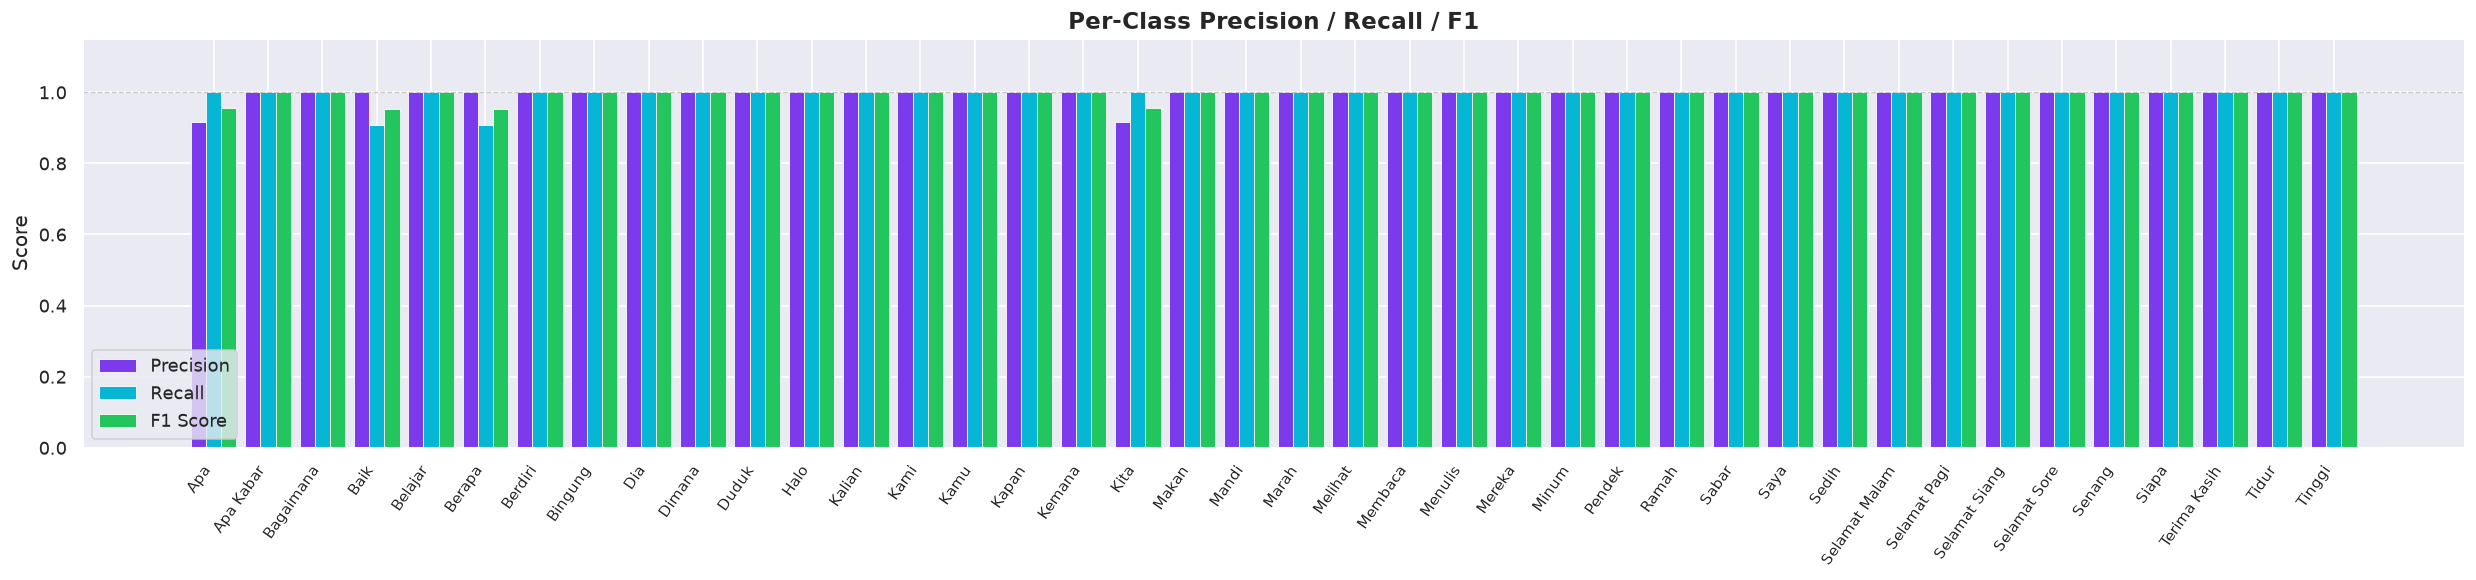

In [23]:
report = classification_report(y_true, y_pred, target_names=actions, output_dict=True)

prec_list = [report[a]['precision'] for a in actions]
rec_list  = [report[a]['recall']    for a in actions]
f1_list   = [report[a]['f1-score']  for a in actions]

x    = np.arange(num_classes)
w    = 0.28

fig, ax = plt.subplots(figsize=(max(14, num_classes * 0.52), 5))
ax.bar(x - w, prec_list, w, label='Precision', color=ACCENT,  edgecolor='white', linewidth=0.5)
ax.bar(x,     rec_list,  w, label='Recall',    color=ACCENT2, edgecolor='white', linewidth=0.5)
ax.bar(x + w, f1_list,   w, label='F1 Score',  color=GREEN,   edgecolor='white', linewidth=0.5)
ax.set_xticks(x)
ax.set_xticklabels(actions, rotation=55, ha='right', fontsize=9)
ax.set_ylim(0, 1.15)
ax.axhline(1.0, color='grey', lw=0.8, linestyle='--', alpha=0.4)
ax.set_title('Per-Class Precision / Recall / F1', fontweight='bold')
ax.set_ylabel('Score')
ax.legend()
plt.tight_layout()
plt.show()


In [24]:
print(classification_report(y_true, y_pred, target_names=actions))


               precision    recall  f1-score   support

          Apa       0.92      1.00      0.96        11
    Apa Kabar       1.00      1.00      1.00        11
    Bagaimana       1.00      1.00      1.00        11
         Baik       1.00      0.91      0.95        11
      Belajar       1.00      1.00      1.00        11
       Berapa       1.00      0.91      0.95        11
      Berdiri       1.00      1.00      1.00        11
      Bingung       1.00      1.00      1.00        11
          Dia       1.00      1.00      1.00        11
       Dimana       1.00      1.00      1.00        11
        Duduk       1.00      1.00      1.00        11
         Halo       1.00      1.00      1.00        11
       Kalian       1.00      1.00      1.00        11
         Kami       1.00      1.00      1.00        11
         Kamu       1.00      1.00      1.00        11
        Kapan       1.00      1.00      1.00        11
       Kemana       1.00      1.00      1.00        11
         

## 10 · Final Summary

In [25]:
print('=' * 50)
print('         SIGNLINGO GRU – TRAINING SUMMARY')
print('=' * 50)
print(f'  Epochs trained : {len(hist["loss"])}')
print(f'  Best epoch     : {best_epoch}')
print(f'  Test Accuracy  : {test_accuracy * 100:.2f}%')
print(f'  Test Loss      : {test_loss:.4f}')
print(f'  Precision      : {prec:.4f}')
print(f'  Recall         : {rec:.4f}')
print(f'  F1 Score       : {f1:.4f}')
print(f'  Model saved    : {MODEL_SAVE_PATH}')
print('=' * 50)


         SIGNLINGO GRU – TRAINING SUMMARY
  Epochs trained : 103
  Best epoch     : 88
  Test Accuracy  : 99.55%
  Test Loss      : 0.0776
  Precision      : 0.9958
  Recall         : 0.9955
  F1 Score       : 0.9954
  Model saved    : signlingo_v2_gru_4.h5
